In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [ ]:
# Convert date column

In [5]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [ ]:
# Set as index

In [6]:
df.set_index('date', inplace=True)

In [7]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


# Plot Time Series

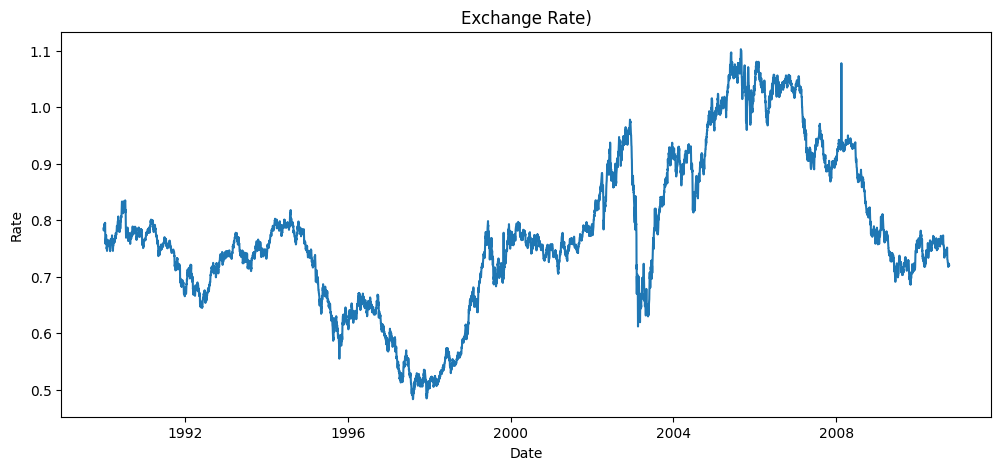

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df.iloc[:,0])
plt.title("Exchange Rate)")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.show()

In [ ]:
# Trend is gradually increasing
lowest at 1998

# Handle Missing Values

In [10]:
df.isnull().sum()

Ex_rate    0
dtype: int64

In [ ]:
# dataset was checked for missing values using the isnull() .
it was observed that there were no missing values in the dataset. no data cleaning was required for missing data.

# ARIMA MODEL

In [12]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 179.0 kB/s eta 0:00:51
   -- ------------------------------------- 0.5/9.5 MB 179.0 kB/s eta 0:00:51
   -- ------------------------------------- 0.5/9.5 MB 179.0 kB/s eta 0:00:51
   -- -


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from statsmodels.tsa.stattools import adfuller

In [14]:
result = adfuller(df.iloc[:,0])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901


In [15]:
df_diff = df.diff().dropna()

# ACF & PACF Plots

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

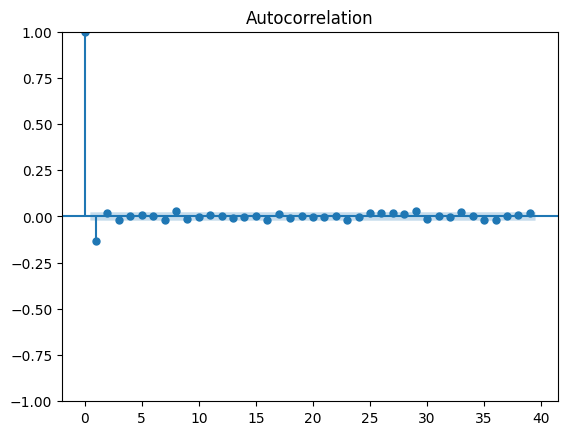

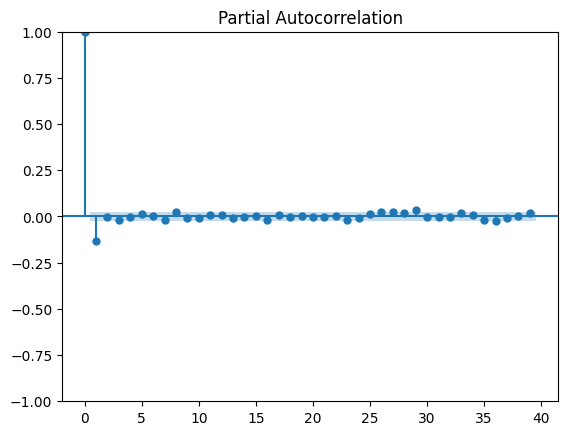

In [17]:
plot_acf(df_diff)
plot_pacf(df_diff)
plt.show()

# Fit ARIMA Model

In [18]:
from statsmodels.tsa.arima.model import ARIMA

In [19]:
model = ARIMA(df.iloc[:,0], order=(1,1,1))  # adjust based on plots
model_fit = model.fit()
print(model_fit.summary())

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Tue, 21 Apr 2026   AIC                         -56102.322
Time:                        06:59:53   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

# Residual Diagnostics

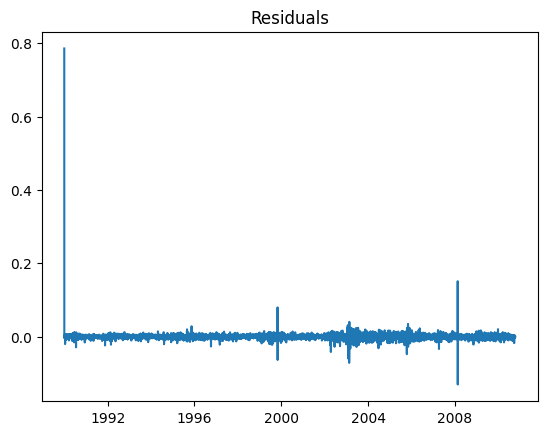

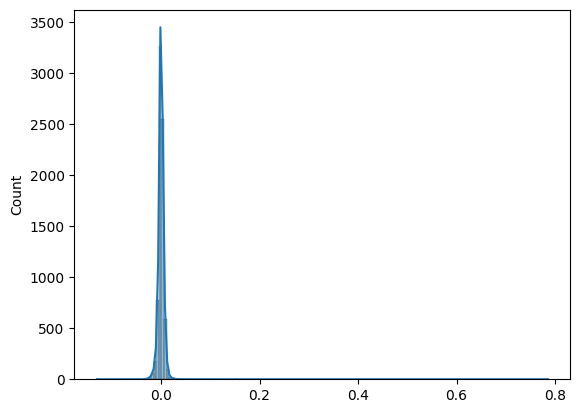

In [20]:
residuals = model_fit.resid
plt.plot(residuals)
plt.title("Residuals")
plt.show()
sns.histplot(residuals, kde=True)
plt.show()

# Forecast

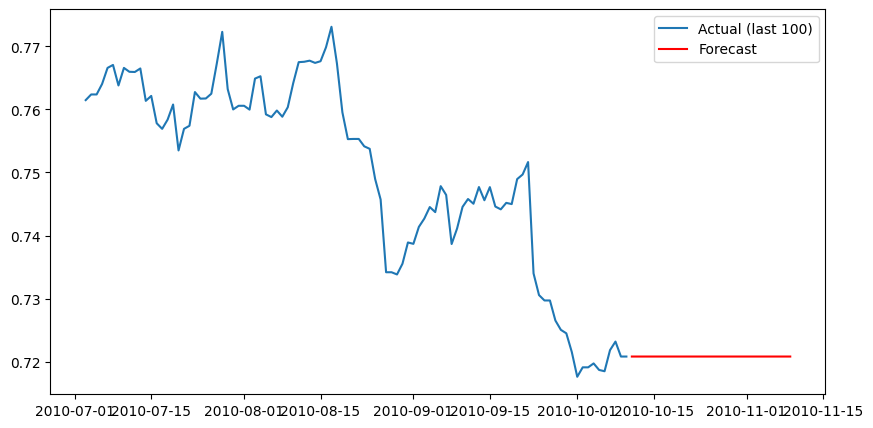

In [22]:
plt.figure(figsize=(10,5))

plt.plot(df['Ex_rate'][-100:], label='Actual (last 100)')
plt.plot(forecast, label='Forecast', color='red')

plt.legend()
plt.show()

In [ ]:
# The forecasted values were plotted alongside historical data using appropriate future date indices. 
This ensured proper alignment of predicted values with the time axis for clear visualization

# EXPONENTIAL SMOOTHING

In [ ]:
# Model Selection

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [24]:
model_es = ExponentialSmoothing(
    df.iloc[:,0],
    trend='add',
    seasonal=None
).fit()

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# Forecast

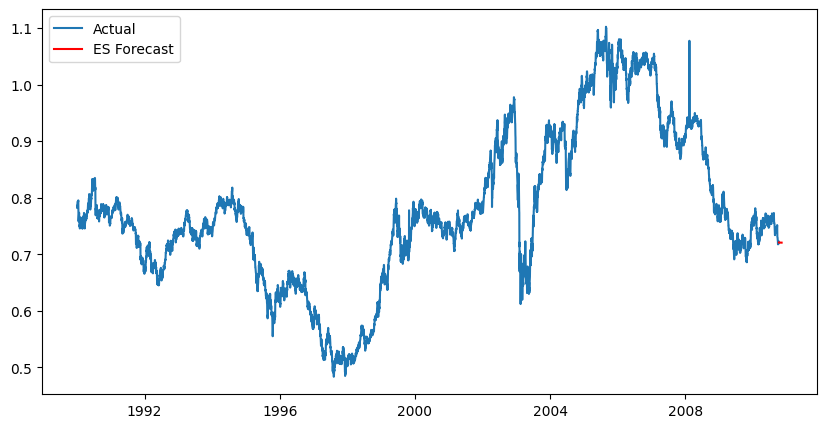

In [26]:
forecast_es = model_es.forecast(30)
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,0], label='Actual')
plt.plot(forecast_es, label='ES Forecast', color='red')
plt.legend()
plt.show()

# Evaluation & Comparison

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [28]:
actual = df.iloc[-30:,0]

mae_arima = mean_absolute_error(actual, forecast)
rmse_arima = np.sqrt(mean_squared_error(actual, forecast))

mae_es = mean_absolute_error(actual, forecast_es)
rmse_es = np.sqrt(mean_squared_error(actual, forecast_es))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ES MAE:", mae_es)
print("ES RMSE:", rmse_es)

ARIMA MAE: 0.012724006489305202
ARIMA RMSE: 0.016982710912755217
ES MAE: 0.012755300148128978
ES RMSE: 0.017004802488117046


In [ ]:
# we used last 30 values for comparison in above step.

# MAPE

In [31]:
def mape(actual, pred):
    actual = np.array(actual)
    pred = np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

print("ARIMA MAPE:", mape(actual, forecast))
print("ES MAPE:", mape(actual, forecast_es))

ARIMA MAPE: 1.7119209757079972
ES MAPE: 1.7161679266060932


# Interpretation

In [ ]:
# The exchange rate time series shows a general trend over time with some fluctuations.
No strong seasonality was observed, but occasional spikes indicate market volatility.